### 2026-02-13 trends

AIMIP evaluations of predicted variable trends in the train (1979-2014, in-sample) and test (2015-2024, out of sample) periods.

In [1]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    ERA5_1DEG,
    EVALUATION_PRESSURE_LEVELS,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_AM4_AMIP_ZARR_TEMPLATE,
    CATEGORICAL_COLORS,
)

In [5]:
TRAINING_DATES = ('1979-10-01', '2014-12-31')
TEST_DATES = ('2015-01-01', '2024-12-31')
DLESYM_TRAINING_DATES = ('1984-01-01', '2014-12-31') # DLESyM actually trained through 2016 so there is no consistent way to present their results here
DLESYM_TEST_DATES = ('2015-01-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = './figures'
CACHE_DIR = './cached'
RESET_CACHE = True
RESTORE_CACHE = False

In [8]:
def linear_fit(x, y):
    fit = np.polyfit(x, y, 1)
    return fit[0], fit[1]

def compute_decadal_trend(ds: xr.Dataset, start: str, end: str, time_dim_name: str) -> xr.Dataset:
    ds_subset = ds.sel(**{time_dim_name: slice(start, end)})
    trends, _ = xr.apply_ufunc(
        linear_fit,
        ds_subset.year / 10,
        ds_subset,
        input_core_dims=[['year'], ['year']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        dask_gufunc_kwargs=dict(allow_rechunk=True),
    )
    return trends

def compute_annual_mean(ds: xr.Dataset, time_dim_name: str='time') -> xr.Dataset:
    annual_mean_ds = ds.groupby(f"{time_dim_name}.year").mean()
    return transfer_attrs(ds, annual_mean_ds)

def compute_global_mean(ds: xr.Dataset, lat_dim: str='lat', lon_dim: str='lon') -> xr.Dataset:
    weights = np.cos(np.deg2rad(ds[lat_dim]))
    global_mean_ds = xr.Dataset()
    global_vars = [var for var in ds.data_vars if all([dim in ds[var].dims for dim in [lat_dim, lon_dim]])]
    for var in global_vars:
        global_mean_ds[var] = ds[var].weighted(weights).mean(dim=[lat_dim, lon_dim])
    return transfer_attrs(ds, global_mean_ds)

In [4]:
monthly_data, _ = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

ACE2.1-ERA5
specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip

In [5]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [6]:
# specific fixes

# add coordinates to DLESyM
monthly_data['DLESyM'] = add_latlon_to_dlesym(monthly_data['DLESyM'])

# ArchesWeather surface temperature has different units (C)
for experiment_submission in ['ArchesWeather-V2', 'ArchesWeatherGen-V2']:
    monthly_data[experiment_submission]['ts'] = monthly_data[experiment_submission].ts + 273.15

In [7]:
# open CMIP6 GFDL AM4 data
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_am4_monthly_1deg, missing_paths = load_gfdl_am4_from_cmip6_gcs(
    GFDL_AM4_AMIP_ZARR_TEMPLATE,
    EVALUATION_VARIABLES,
    other_variables,
    version_tag_mapping={'hus': 'v20180301'},
)
monthly_data['GFDL-AM4'] = gfdl_am4_monthly_1deg.expand_dims({'realization': [1]})

gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/hus/gr1/v20180301
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/huss/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/pr/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/ps/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/psl/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/ta/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/tas/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/ts/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/ua/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/uas/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/va/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/vas/gr1/v20180807
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-AM4/amip/r1i1p1f1/Amon/zg/gr1/v2

In [8]:
era5_monthly_1deg, _ = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze().drop_vars('realization')
    .drop_vars(['forecast_period', 'originating_centre'])
)

ERA5
specific_humidity
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_hus_1978-2024.nc
surface_specific_humidity
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc
dew_point_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc
precipitation_flux
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_air_pressure
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ps_1978-2024.nc
air_pressure_at_sea_level
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc
air_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc
air_temperature


/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:561: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:561: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' att

../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tas_1978-2024.nc
surface_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
eastward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ua_1978-2024.nc
eastward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_uas_1978-2024.nc
northward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_va_1978-2024.nc
northward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_vas_1978-2024.nc
geopotential_height
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_zg_1978-2024.nc


/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:561: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:561: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' att

In [9]:
era5_monthly_1deg = convert_tdas_to_huss(era5_monthly_1deg)

Converting 'tdas' to 'huss'.


In [10]:
annual_mean_data = {}
for experiment_submission_name, dataset in monthly_data.items():
    print(experiment_submission_name)
    annual_mean = compute_annual_mean(dataset)
    annual_mean_data[experiment_submission_name] = annual_mean
annual_mean_era5 = compute_annual_mean(era5_monthly_1deg)

ACE2.1-ERA5
ArchesWeather-V2
ArchesWeatherGen-V2
cBottle1.3
DLESyM
MD1.5
NeuralGCM
NeuralGCM-HRD
GFDL-AM4


In [11]:
with ProgressBar():
    annual_mean_data = {
        k: v.compute() for k, v in annual_mean_data.items()
    }
    annual_mean_era5 = annual_mean_era5.compute()

[########################################] | 100% Completed | 133.41 s
[########################################] | 100% Completed | 149.32 s
[########################################] | 100% Completed | 150.38 s
[########################################] | 100% Completed | 268.62 s
[########################################] | 100% Completed | 6.21 ss
[########################################] | 100% Completed | 307.13 s
[########################################] | 100% Completed | 106.82 s
[########################################] | 100% Completed | 139.13 s
[########################################] | 100% Completed | 22.84 s
[########################################] | 100% Completed | 94.83 ss


In [12]:
regridded_annual_means = []
for experiment_submission_name, dataset in annual_mean_data.items():
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    target_grid = annual_mean_era5.isel(year=0)[['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    regridded_annual_mean = regrid_dataset(
        dataset,
        target_grid,
        sample_dims=['realization', 'year'],
        **regridder_kwargs
    )
    regridded_annual_means.append(
        regridded_annual_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_annual_means = xr.concat(regridded_annual_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5
ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM
MD1.5
NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

GFDL-AM4


In [13]:
regridded_annual_means = regridded_annual_means.sel(year=slice(1979, 2024)) # full years only
regridded_annual_means.loc[{'experiment_submission': 'DLESyM', 'year': 1983}] = np.nan # actually starts midway through 1983
annual_mean_era5 = annual_mean_era5.sel(year=slice(1979, 2024))

In [14]:
if RESET_CACHE:
    path_annual_mean = os.path.join(CACHE_DIR, 'regridded_annual_means.nc')
    path_annual_mean_era5 = os.path.join(CACHE_DIR, 'annual_mean_era5.nc')
    try:
        os.remove(path_annual_mean)
        os.remove(path_annual_mean_era5)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    regridded_annual_means.to_netcdf(path_annual_mean)
    annual_mean_era5.to_netcdf(path_annual_mean_era5)
    print("Cache updated.")

Cache updated.


In [6]:
if RESTORE_CACHE: 
    path_annual_mean = os.path.join(CACHE_DIR, 'regridded_annual_means.nc')
    path_annual_mean_era5 = os.path.join(CACHE_DIR, 'annual_mean_era5.nc')
    regridded_annual_means = xr.open_dataset(path_annual_mean)
    annual_mean_era5 = xr.open_dataset(path_annual_mean_era5)

In [9]:
regridded_global_annual_means = compute_global_mean(regridded_annual_means.drop_sel(experiment_submission='NeuralGCM-HRD'))
global_annual_mean_era5 = compute_global_mean(annual_mean_era5)

In [10]:
# can't use 1000, 850, 700 hPa height metrics for CMIP6 GFDL-AM4 to compute global means
# because is masked for topography (unlike ERA5-based datasets that are not)

for var in regridded_global_annual_means.data_vars:
    if "plev" in regridded_global_annual_means[var].coords:
        regridded_global_annual_means[var].loc[{'experiment_submission': 'GFDL-AM4'}] = (
            regridded_global_annual_means[var]
            .sel(experiment_submission='GFDL-AM4')
            .where(regridded_global_annual_means.plev <= 5.0e4)
        )

In [11]:
global_mean_trend_training_no_dlesym = compute_decadal_trend(
    regridded_global_annual_means.drop_sel(experiment_submission='DLESyM'),
    start=TRAINING_DATES[0],
    end=TRAINING_DATES[1],
    time_dim_name='year',
)
global_mean_trend_training_dlesym = compute_decadal_trend(
    regridded_global_annual_means.sel(experiment_submission=['DLESyM']),
    start=DLESYM_TRAINING_DATES[0],
    end=DLESYM_TRAINING_DATES[1],
    time_dim_name='year',
)
global_mean_trend_training = xr.concat(
    [
        global_mean_trend_training_no_dlesym,
        global_mean_trend_training_dlesym
    ],
    dim='experiment_submission'
)
global_mean_trend_test_no_dlesym = compute_decadal_trend(
    regridded_global_annual_means.drop_sel(experiment_submission='DLESyM'),
    start=TEST_DATES[0],
    end=TEST_DATES[1],
    time_dim_name='year',
)
global_mean_trend_test_dlesym = compute_decadal_trend(
    regridded_global_annual_means.sel(experiment_submission=['DLESyM']),
    start=DLESYM_TEST_DATES[0],
    end=DLESYM_TEST_DATES[1],
    time_dim_name='year',
)
global_mean_trend_test = xr.concat(
    [
        global_mean_trend_test_no_dlesym,
        global_mean_trend_test_dlesym
    ],
    dim='experiment_submission'
)
global_mean_trend = xr.concat(
    [
        global_mean_trend_training.expand_dims({'time_period': ['training']}), 
        global_mean_trend_test.expand_dims({'time_period': ['test']}), 
    ],
    dim='time_period',
).sel(experiment_submission=regridded_global_annual_means.experiment_submission, plev=EVALUATION_PRESSURE_LEVELS)

In [12]:
global_mean_trend_training_era5 = compute_decadal_trend(global_annual_mean_era5, start=TRAINING_DATES[0], end=TRAINING_DATES[1], time_dim_name='year')
global_mean_trend_test_era5 = compute_decadal_trend(global_annual_mean_era5, start=TEST_DATES[0], end=TEST_DATES[1], time_dim_name='year')
global_mean_trend_era5 = xr.concat(
    [
        global_mean_trend_training_era5.expand_dims({'time_period': ['training']}), 
        global_mean_trend_test_era5.expand_dims({'time_period': ['test']}), 
    ],
    dim='time_period',
).sel(plev=EVALUATION_PRESSURE_LEVELS)

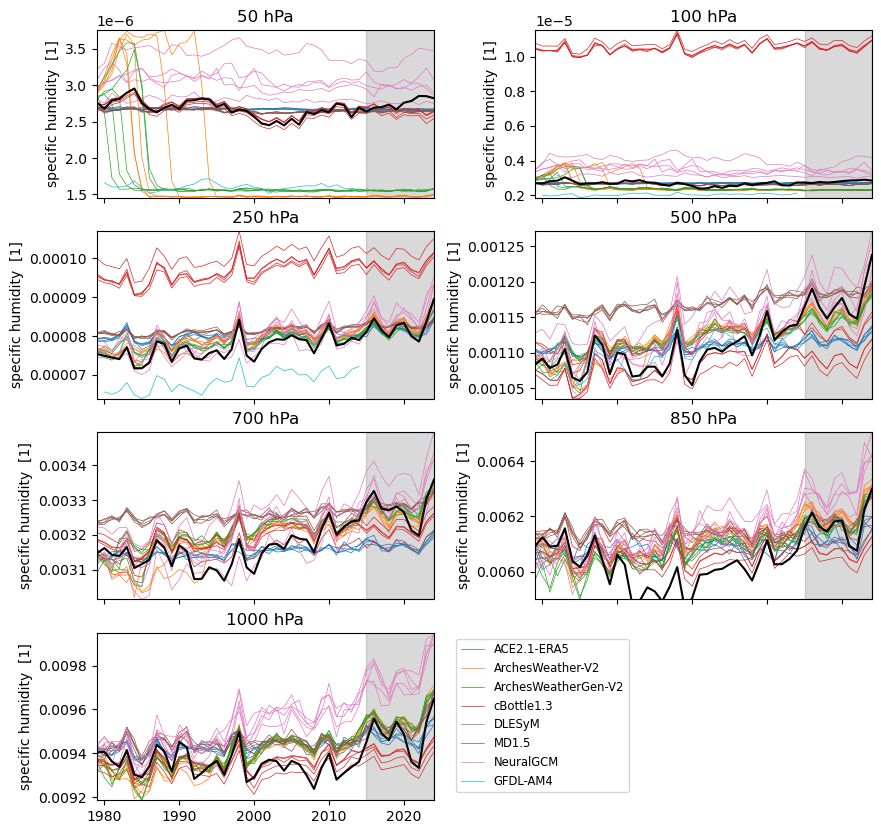

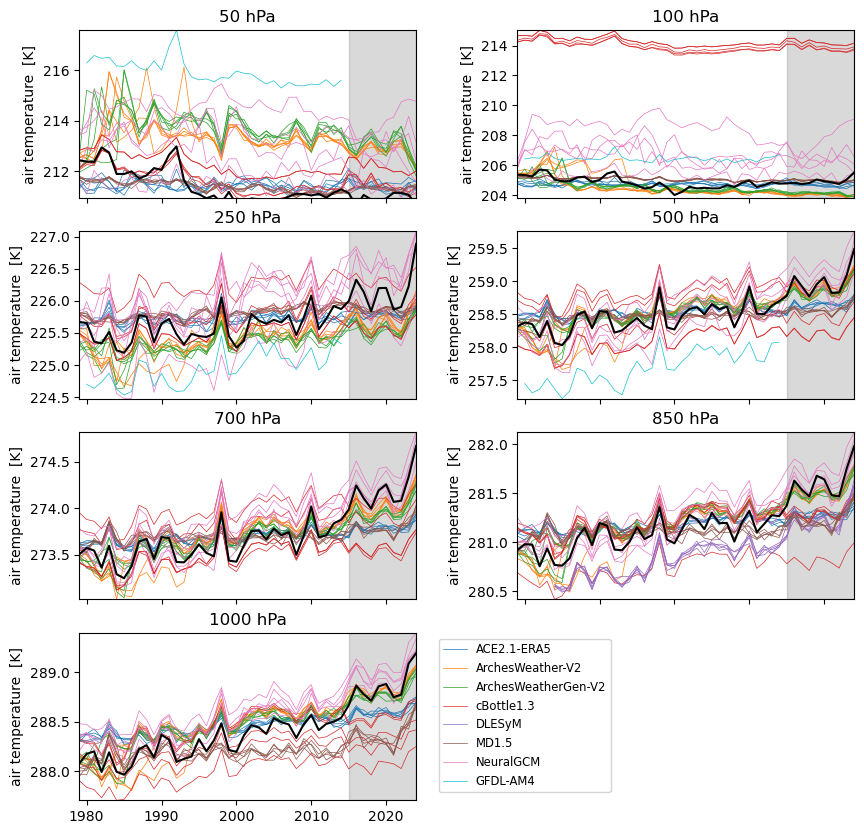

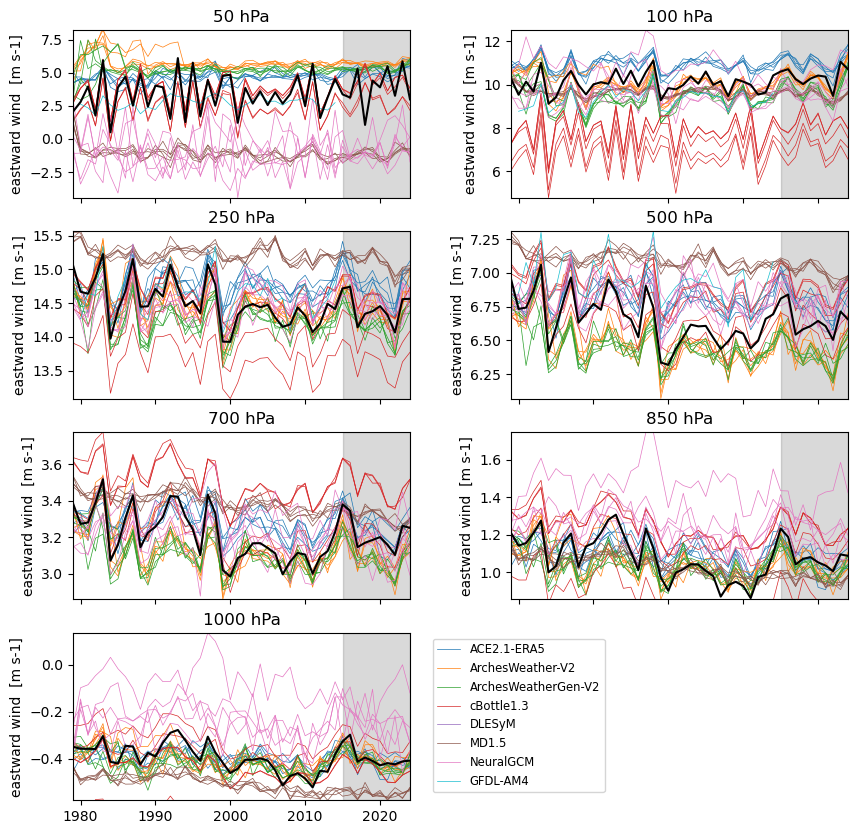

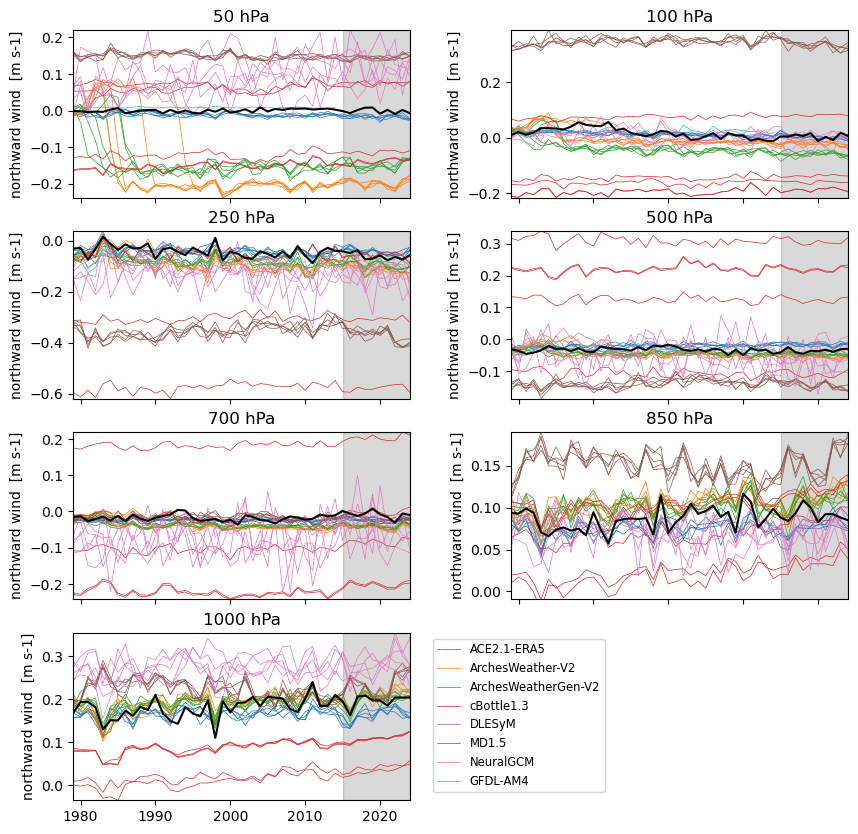

In [13]:
pressure_vars = [var for var in regridded_global_annual_means.data_vars if "plev" in regridded_global_annual_means[var].dims]
for pressure_var in pressure_vars:
    fig, axes = plt.subplots(
        nrows=int(np.ceil(regridded_global_annual_means.sizes["plev"] / 2)),
        ncols=2,
        figsize=(10, 10),
        sharex=True,
        sharey=False,
    )
    for ax, plev in zip(axes.flatten(), regridded_global_annual_means.coords["plev"]):
        handles = []
        for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
            h = regridded_global_annual_means[pressure_var].sel(plev=plev, experiment_submission=experiment_submission).plot(
                ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
            )
            handles.append(h[0])
        global_annual_mean_era5[pressure_var].sel(plev=plev).plot(ax=ax, color='k', lw=1.5)
        scale_data = regridded_global_annual_means[pressure_var].sel(plev=plev).drop_sel(realization=2)
        ylim = scale_data.min().item(), scale_data.max().item()
        xlim = 1979, 2024
        ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
        ax.set_xlim([xlim[0], xlim[1]])
        ax.set_ylim([ylim[0], ylim[1]])
        ax.set_title(f"{str(int(plev.item() / 100))} hPa")
        ax.set_ylabel(
            f"{regridded_global_annual_means[pressure_var].attrs.get('long_name', pressure_var)} "
            f" [{regridded_global_annual_means[pressure_var].attrs.get('units', '-')}]"
        )
        ax.set_xlabel(None)
        if ax is axes.flatten()[-2]:
            axes.flatten()[-1].set_axis_off()
            ax.legend(
                handles,
                regridded_global_annual_means.coords["experiment_submission"].values,
                bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
            )
    fig.subplots_adjust(wspace=0.3)
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_series_{pressure_var}.png"), bbox_inches='tight')

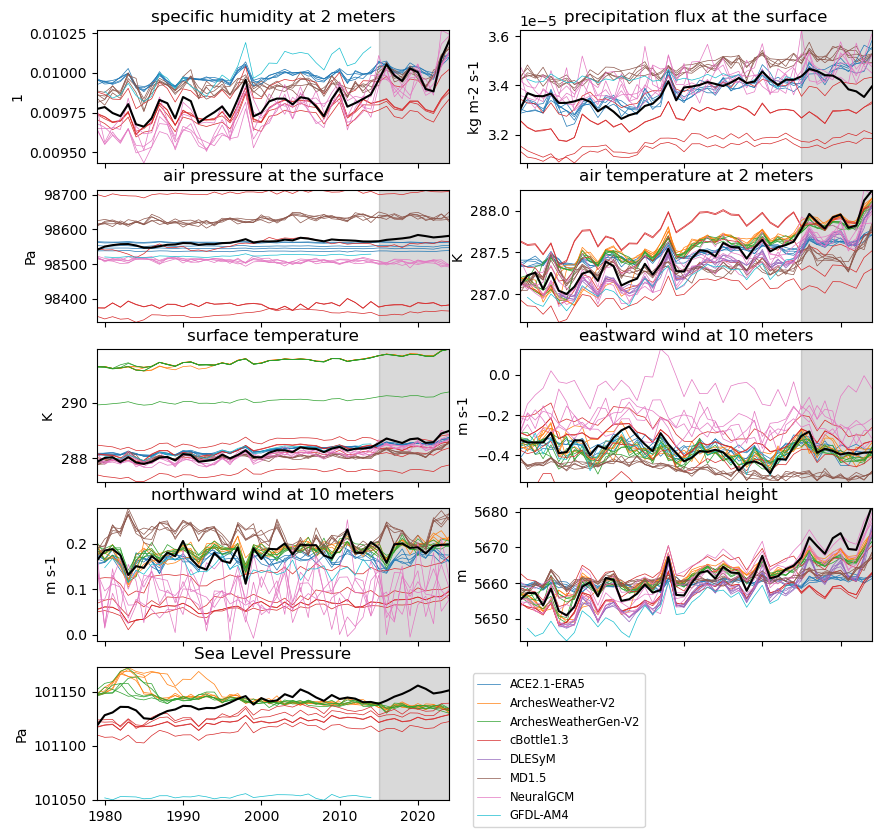

In [20]:
surface_vars = [var for var in regridded_global_annual_means.data_vars if "plev" not in regridded_global_annual_means[var].dims]
fig, axes = plt.subplots(nrows=int(np.ceil(len(surface_vars) / 2)), ncols=2, figsize=(10, 10), sharex=True, sharey=False)
for ax, surface_var in zip(axes.flatten(), surface_vars):
    handles = []
    for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
        h = regridded_global_annual_means[surface_var].sel(experiment_submission=experiment_submission).plot(
            ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
        )
        handles.append(h[0])
    if surface_var in global_annual_mean_era5.data_vars:
        global_annual_mean_era5[surface_var].plot(ax=ax, color='k', lw=1.5)
    scale_data = regridded_global_annual_means[surface_var].drop_sel(realization=2)
    ylim = scale_data.min().item(), scale_data.max().item()
    xlim = 1979, 2024
    ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xlim([xlim[0], xlim[1]])
    ax.set_ylim([ylim[0], ylim[1]])
    ax.set_ylabel(f"{regridded_global_annual_means[surface_var].attrs.get('units', '-')}")
    ax.set_title(f"{regridded_global_annual_means[surface_var].attrs.get('long_name', surface_var)}")
    ax.set_xlabel(None)
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(
            handles,
            regridded_global_annual_means.coords["experiment_submission"].values,
            bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
        )
fig.patch.set_alpha(0.0)
fig.savefig(os.path.join(OUTDIR, f"trend_series_surface_vars.png"), bbox_inches='tight')

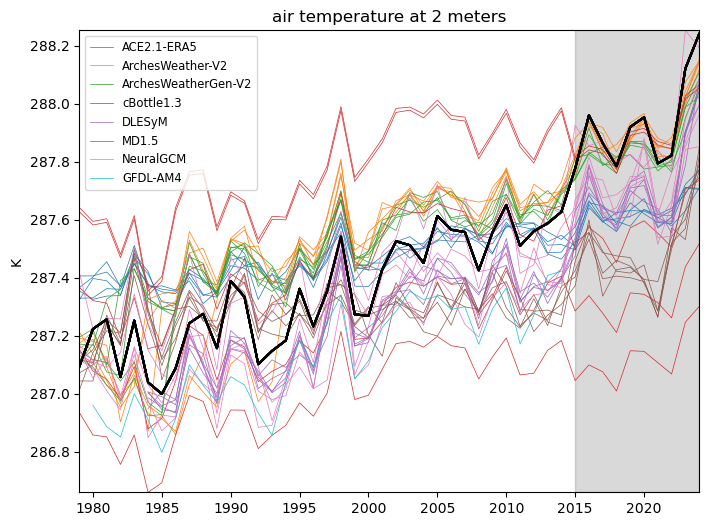

In [21]:
# TMP2m only version of global+annual series plot
fig, ax = plt.subplots(figsize=(8, 6))
handles = []
for i, experiment_submission in enumerate(regridded_global_annual_means.coords["experiment_submission"]):
    h = regridded_global_annual_means['tas'].sel(experiment_submission=experiment_submission).plot(
        ax=ax, hue='realization', color=CATEGORICAL_COLORS[i], add_legend=False, lw=0.5
    )
    handles.append(h[0])
    global_annual_mean_era5['tas'].plot(ax=ax, color='k', lw=1.5)
scale_data = regridded_global_annual_means['tas']
ylim = scale_data.min().item(), scale_data.max().item()
xlim = 1979, 2024
ax.fill_between([2015, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
ax.set_xlim([xlim[0], xlim[1]])
ax.set_ylim([ylim[0], ylim[1]])
ax.set_ylabel(f"{regridded_global_annual_means['tas'].attrs.get('units', '-')}")
ax.set_title(f"{regridded_global_annual_means['tas'].attrs.get('long_name', surface_var)}")
ax.set_xlabel(None)
ax.legend(
    handles,
    regridded_global_annual_means.coords["experiment_submission"].values,
    fontsize='small',
)
fig.patch.set_alpha(0.0)
fig.savefig(os.path.join(OUTDIR, f"trend_series_tas.png"), bbox_inches='tight')

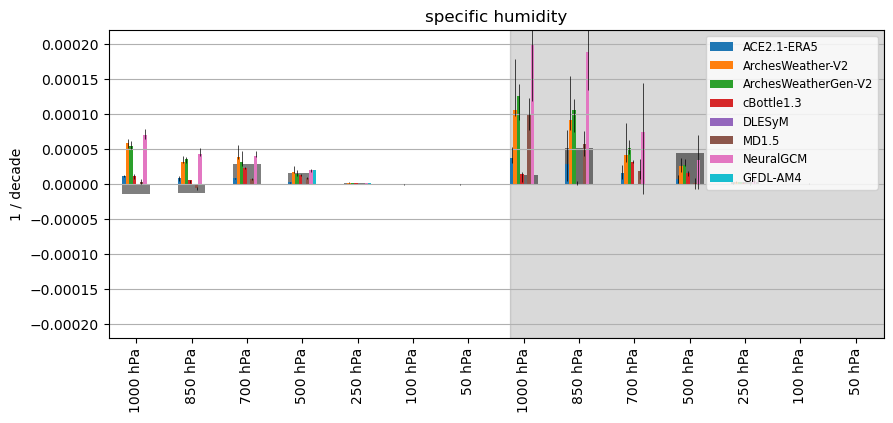

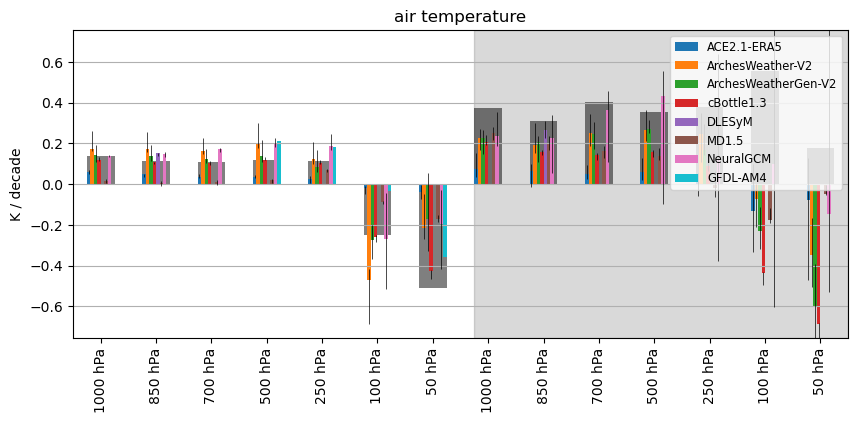

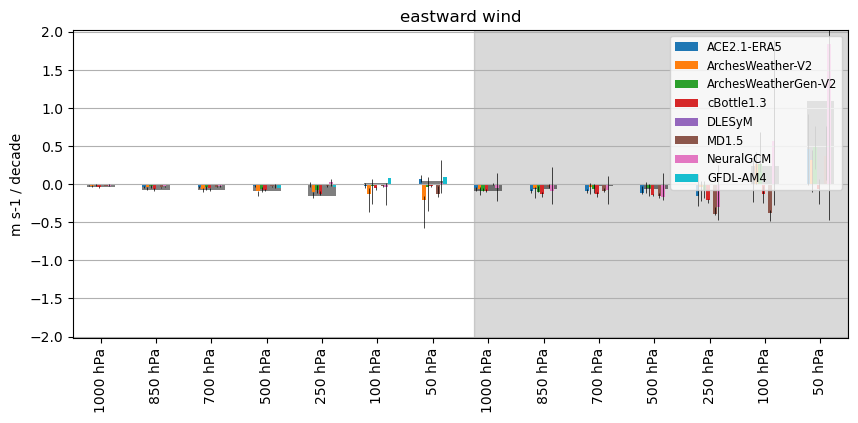

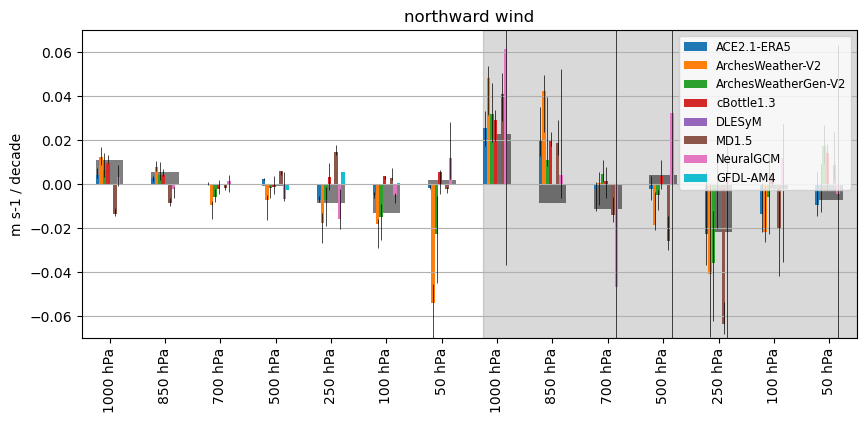

In [14]:
for pressure_var in pressure_vars:
    fig, ax = plt.subplots(figsize=(10, 4))
    trends = (
        global_mean_trend[pressure_var].transpose('time_period', 'plev', 'experiment_submission', 'realization')
    )
    lowest, median, highest = (
        trends.min('realization').to_dataframe().unstack(),
        trends.median('realization').to_dataframe().unstack(),
        trends.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    (
        global_mean_trend_era5[pressure_var]
        .to_dataframe()
        .plot.bar(ax=ax, color='k', zorder=-1, legend=False, alpha=0.5)
    )
    ax.legend(trends.experiment_submission.values, fontsize='small')
    ax.grid(axis='y')
    xlim = ax.get_xlim()
    yscale = 1.1 * max([
        np.abs(trends.median('realization')).max().item(),
        np.abs(global_mean_trend_era5[pressure_var]).max().item(),
    ])
    ylim = -yscale, yscale
    ax.fill_between([xlim[1] / 2, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([f"{str(round(ind[1]/100))} hPa" for ind in median.index])
    ax.set_ylabel(f"{regridded_global_annual_means[pressure_var].attrs.get('units', pressure_var)} / decade")
    ax.set_title(f"{regridded_global_annual_means[pressure_var].attrs.get('long_name', pressure_var)}")
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_mean_{pressure_var}.png"), bbox_inches="tight")

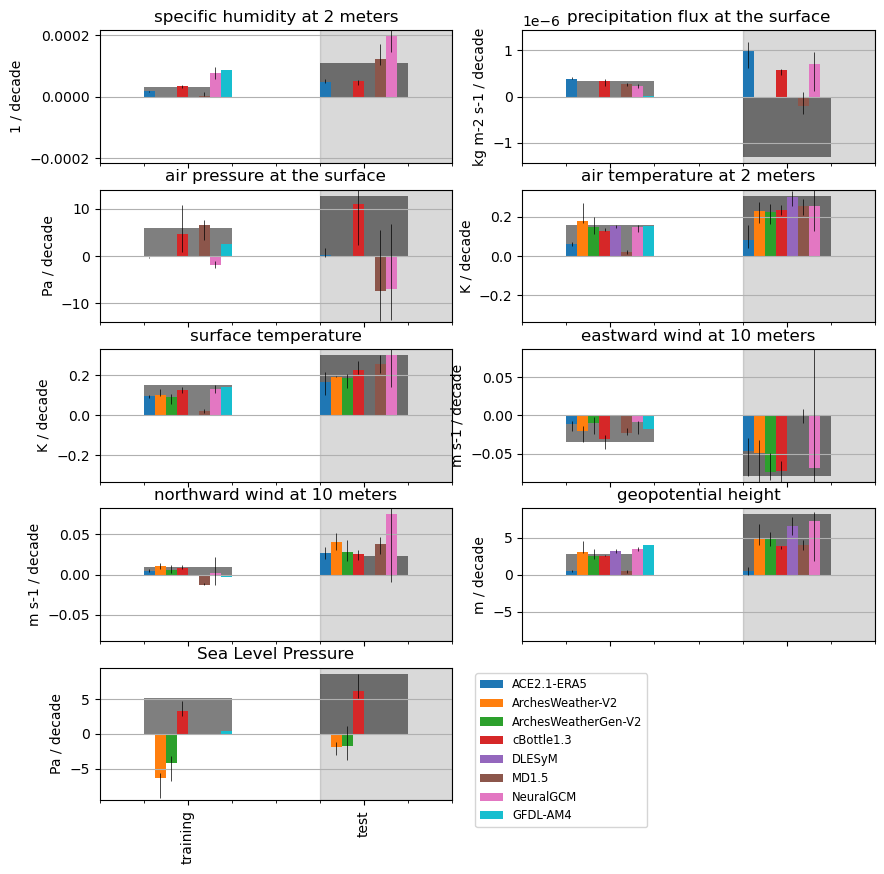

In [31]:
fig, axes = plt.subplots(sharex=True, ncols=2, nrows=int(np.ceil(len(surface_vars) / 2)), figsize=(10, 10))
for ax, surface_var in zip(axes.flatten(), surface_vars):
    trends = (
        global_mean_trend[surface_var].transpose('time_period', 'experiment_submission', 'realization')
    )
    lowest, median, highest = (
        trends.min('realization').to_dataframe().unstack(),
        trends.median('realization').to_dataframe().unstack(),
        trends.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax, legend=False, color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if surface_var in global_mean_trend_era5.data_vars:
        (
            global_mean_trend_era5[surface_var]
            .to_dataframe().unstack()
            .plot.bar(ax=ax, color='k', zorder=-1, legend=False, alpha=0.5)
        )
    ax.grid(axis='y')
    xlim = ax.get_xlim()
    yscale = 1.1 * max([
        np.abs(trends.median('realization')).max().item(),
        np.abs(global_mean_trend_era5[surface_var]).max().item(),
    ])
    ylim = -yscale, yscale
    ax.fill_between([xlim[1] / 2, xlim[1]], [ylim[0], ylim[0]], [ylim[1], ylim[1]], color='k', alpha=0.15, zorder=-1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('')
    ax.set_xticklabels([time_period for time_period in global_mean_trend['time_period'].values])
    ax.set_ylabel(f"{regridded_global_annual_means[surface_var].attrs.get('units', surface_var)} / decade")
    ax.set_title(f"{regridded_global_annual_means[surface_var].attrs.get('long_name', surface_var)}")
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(
            [patch for patch in ax.patches[::2]],
            regridded_global_annual_means.coords["experiment_submission"].values,
            bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small'
        )
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"trend_mean_surface_variables.png"), bbox_inches="tight")